# NB13a: OOF Overlap Analysis v2

> Copyright (C) 2024-2026 Marco Heinzen - SPDX-License-Identifier: AGPL-3.0-or-later
> Part of the Master Thesis "Building Damage Assessment with Multimodal Satellite Time Series and Machine Learning in the Russia-Ukraine War 2022-2026"
> Code hosted at https://github.com/marcoheinzen/bda
> Parts of this code were written or improved with the assistance of Claude (Anthropic); all other code, and the concept, research, architecture, design, execution, testing and validation throughout, are the author's work.


Consumes the canonical OOF prediction parquets produced by NB07 / NB08a / NB08b / NB08c / NB09a / NB09b / NB09c / NB09d / NB09e (after retrofit — see `NB13_OOF_Schema_Handover.md`).

Central question: **do all models mark the same buildings as damaged?**

Sections:
- M1 DISCOVERY — find every `oof_*.parquet` under `RESULTS_ROOT` and the NB09d output root
- M2 LOAD + DEDUP — concat all parquets, keep latest per `model_id` when duplicates
- M3 PER-MODEL SANITY — AUC + TP/FN/FP/TN per model, filter out anything suspicious
- M4 PIVOT — build (building × model) wide matrices for `y_pred`, `y_proba`, `cm_class`
- M5 PAIRWISE COHEN's κ — supervised-only agreement heatmap with hierarchical clustering
- M6 JACCARD on FP / FN SETS — do models confuse the same buildings?
- M7 FLEISS' κ — multi-rater reliability across supervised models
- M8 HARD-FOR-ALL — buildings every model misclassifies; join with metadata for NB11b stratification
- M9 LEAKAGE DELTA — random_cv vs groupkfold OOF comparison on same underlying model
- M10 SAVE + SUMMARY — CSV artefacts for thesis figures

This is an ANALYSIS notebook, not a pipeline stage — it does not write any new `oof_*.parquet`.

# CONFIG + GLOBAL SETUP

In [1]:
# @title CELL 3: NB11a CONFIG + GLOBAL SETUP
import sys, os
from pathlib import Path

import platform, os
if platform.system() == "Windows":
    _setup = r"F:\PROJECTS\masterthesis\gdrive\masterthesis\notebooks\global_setup.py"
elif os.path.exists("/content/drive_f"):
    _setup = "/content/drive_f/masterthesis/notebooks/global_setup.py"
else:
    _setup = "/mnt/f/PROJECTS/masterthesis/gdrive/masterthesis/notebooks/global_setup.py"
with open(_setup) as f:
    exec(f.read())


# --- tier / city selection (match upstream notebooks) ------------------
TIER_SELECTION = [0, 1, 2]
CITY_SELECTION = None
REQUIRE_UNOSAT = True
RANDOM_STATE = 42

# --- NB11a-specific config --------------------------------------------
# threshold for "hard for all" (fraction of models that misclassify a building)
HARD_FOR_ALL_THRESHOLD = 0.90

# exclude these variant_id substrings from headline overlap (kept for leakage section)
LEAKAGE_VARIANT_MARKERS = [
    'leakage_demo', 'random_cv', 'geographic_70_30',
]

# directories to search for oof_*.parquet (recursive). Add more if needed.
OOF_SEARCH_ROOTS = [RESULTS_ROOT]
# NB09d writes to OUTPUT_ROOT under CONTENT_LOCAL by default; include if present
try:
    _nb09d_root = CONTENT_LOCAL / 'nb09d_dl_experiments'
    if _nb09d_root.exists():
        OOF_SEARCH_ROOTS.append(_nb09d_root)
except NameError:
    pass

# --- NB11 hyperparameter-tuning OOF parquets (added in v6) ----------
try:
    _nb11_root = OUTPUTS_DIR / 'NB11_V2' / 'oof'
    if _nb11_root.exists():
        OOF_SEARCH_ROOTS.append(_nb11_root)
except NameError:
    pass

print(f"  OOF search roots:")
for r in OOF_SEARCH_ROOTS:
    print(f"    {r}")
print(f"  TIER_SELECTION: {TIER_SELECTION}")
print(f"  HARD_FOR_ALL_THRESHOLD: {HARD_FOR_ALL_THRESHOLD}")


BDA GLOBAL SETUP
Started: 2026-07-03 08:43:23
Python: 3.12.12

[1/7] Directory Structure
----------------------------------------------------------------------
  GDrive (G:):       /content/drive_f/masterthesis OK
  GDrive (F:):       /content/drive_f/masterthesis OK
  Local data (G:):   /content/masterthesis_local/data OK
  Data stack (F:):   /mnt/f/PROJECTS/masterthesis/data_stack OK


/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)



  TIER_SELECTION: [0, 1, 2]
  CITY_SELECTION: None (tier filter)
  REQUIRE_UNOSAT: False
  CITIES_TO_PROCESS: 21 cities

[2/7] Credentials
----------------------------------------------------------------------
  Copernicus: inf***
  OpenTopography: OK
  Earthdata: marcoheinzen

[3/7] Python Packages
----------------------------------------------------------------------


<string>:564: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



  Already installed: 23
  Newly installed:   0
  Failed:            0

[4/7] Global Imports & Configuration
----------------------------------------------------------------------
  All imports loaded

[5/7] Processing Config & SNAP
----------------------------------------------------------------------
  GPT: Usage:
  Temporal baseline: 10-24 days
  Wavelength: 0.0555

[6/7] GPU Status
----------------------------------------------------------------------
  CUDA available: NVIDIA GeForce RTX 2070 SUPER
    CUDA version: 12.8

[7/7] Disk Space
----------------------------------------------------------------------
  GDrive (G:)     930.7/7452.0 GB (6521.3 GB free)
  GDrive (F:)     1405.7/3726.0 GB (2320.3 GB free)
  Local data      11563.4/14901.9 GB (3338.4 GB free)
  Data stack      1405.7/3726.0 GB (2320.3 GB free)
  WSL ext4        69.1/1006.9 GB (886.6 GB free)

GLOBAL SETUP COMPLETE
  Torch device: cuda
  Cities: 21, CITY=Avdiivka
  Functions: load_aoi(), load_aoi_gdf(), load_aoi_

# CELL S0: BUILDINGS + HELPERS + OUTPUT PATHS
Loads building metadata for joining with OOF predictions, defines output helpers, sets up output dir.

In [2]:
# @title CELL S0: METADATA + HELPERS + OUTPUT PATHS
import json, gc
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime as _dt
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

print("=" * 70)
print("CELL S0: NB11a OVERLAP ANALYSIS -- SETUP (A/B GROUPS + MODALITY)")
print("=" * 70)

if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

import oof_loader
import importlib
importlib.reload(oof_loader)
from oof_loader import (
    GROUP_A, GROUP_B, SAMPLE_ID_COL,
    discover_oof_parquets, load_all_oof,
    load_metadata_both, check_y_true_consistency,
    build_model_sanity, pivot_oof,
)

# --- resolve cities ---------------------------------------------------
CITIES_TO_PROCESS, _battle_dates = resolve_cities(
    tier_selection=TIER_SELECTION,
    city_selection=[CITY_SELECTION] if isinstance(CITY_SELECTION, str) else CITY_SELECTION,
    require_unosat=REQUIRE_UNOSAT,
)
print(f"  Cities: {len(CITIES_TO_PROCESS)}")

# --- load BOTH metadata sets -----------------------------------------
_tiers = TIER_SELECTION if isinstance(TIER_SELECTION, list) else [0, 1, 2]
DATASET_ROOT_V3 = STACK_DIR / 'dataset' / 'v3'

meta = load_metadata_both(
    dataset_root_v2=DATASET_ROOT_V2,
    dataset_root_v3=DATASET_ROOT_V3,
    tiers=_tiers,
    cities=CITIES_TO_PROCESS,
    load_tier_parquets_fn=load_tier_parquets,
)
df_bldg = meta['buildings_df']
df_pts  = meta['points_df']

TARGET_COL = 'damage_binary'

# --- modality classifier (shared with NB11c) --------------------------
def classify_modality(model_id, variant_id):
    combined = (str(model_id) + ' ' + str(variant_id)).lower()
    # --- NB11 explicit parquet -> modality lookup (added in v6) --------
    # NB11 model_ids look like 'NB11<a-f>_<tag>__<manifest_key>__<clf>-Optuna'.
    # We check manifest_key tokens FIRST so they take precedence over the
    # token-substring matchers below (which would otherwise miss 'fusion_*').
    _nb11_modality = {
        # SAR-only
        'card_drop':                  'SAR_card_only',
        'prepost_single_card':        'SAR_card_only',
        'coh_drop':                   'SAR_coh_only',
        'rolling_accum_coh':          'SAR_coh_only',
        # SAR + COH fused (no MS)
        'fusion_card_cohdrop':        'SAR_card+coh',
        # multimodal (SAR + MS, +/- COH)
        'fusion_ms_card_cohdrop':     'multimodal_all',
        'fusion_indices_card_cohdrop':'multimodal_all',
        'fusion_ms_cohdrop':          'multimodal_SAR+MS',
        'fusion_composite_cohdrop':   'multimodal_all',
        'fusion_composite_blockstats':'multimodal_all',
        'block_stats':                'multimodal_all',
        'rolling_stats_roll3':        'multimodal_all',
        'rolling_stats_roll7':        'multimodal_all',
        'rolling_stats_roll13':       'multimodal_all',
        # MS-only
        'ms_change':                  'MS_only',
        'composite_prepost_bands':    'MS_only',
        'composite_vs_scenes_bands':  'MS_only',
        # land-use (own family)
        'lu_change':                  'other',
        'composite_prepost_landuse':  'other',
        'composite_vs_scenes_landuse':'other',
    }
    if 'nb11' in combined:
        for _key, _mod in _nb11_modality.items():
            if _key in combined:
                return _mod
    if any(x in combined for x in ['coh_drop', 'coh_running', 'coh_max_drop']):
        return 'SAR_coh_unsupervised'
    if 'logratio' in combined:
        if any(x in combined for x in ['ndvi', 'savi', 'bsi', 'nbr', 'ndbi']):
            return 'MS_unsupervised'
        return 'SAR_unsupervised'
    if 'card_only' in combined or 'sensor=card;' in combined or combined.endswith('sensor=card'):
        return 'SAR_card_only'
    if 'coh_only' in combined or 'sensor=coh;' in combined or combined.endswith('sensor=coh'):
        return 'SAR_coh_only'
    if 'card+coh' in combined or 'sensor=card+coh' in combined:
        return 'SAR_card+coh'
    if 'ms_only' in combined or 'sensor=ms' in combined:
        return 'MS_only'
    if 'nb08b' in combined:
        if 'rgb' in combined and ('card' in combined or 'coh' in combined):
            return 'multimodal_SAR+MS'
        if 'rgb' in combined:
            return 'MS_only'
    if 'all_multimodal' in combined or 'all features' in combined:
        return 'multimodal_all'
    if 'parquet=f7' in combined or 'parquet=a17' in combined:
        return 'multimodal_all'
    if 'sar_only' in combined:
        return 'SAR_all'
    if 'sar + ms + coh' in combined:
        return 'multimodal_all'
    if 'sar + ms' in combined:
        return 'multimodal_SAR+MS'
    return 'other'

MODALITY_FAMILIES = {
    'SAR': ['SAR_card_only', 'SAR_coh_only', 'SAR_card+coh', 'SAR_all',
            'SAR_coh_unsupervised', 'SAR_unsupervised'],
    'MS':  ['MS_only', 'MS_unsupervised'],
    'multimodal': ['multimodal_all', 'multimodal_SAR+MS'],
}

def modality_family(mod):
    for fam, members in MODALITY_FAMILIES.items():
        if mod in members:
            return fam
    return 'other'

FAMILY_COLORS = {'SAR': '#e41a1c', 'MS': '#377eb8', 'multimodal': '#4daf4a', 'other': '#999999'}

# --- output dir -------------------------------------------------------
OUT_DIR = RESULTS_ROOT / 'nb11a'
OUT_DIR.mkdir(parents=True, exist_ok=True)

def save_result(data, name, cell_id, fmt='csv'):
    cell_dir = OUT_DIR / cell_id
    cell_dir.mkdir(parents=True, exist_ok=True)
    ts = _dt.now().strftime('%Y%m%d_%H%M%S')
    if fmt == 'csv' and isinstance(data, pd.DataFrame):
        path = cell_dir / f"{name}_{ts}.csv"
        data.to_csv(path, index=False)
    elif fmt == 'json':
        path = cell_dir / f"{name}_{ts}.json"
        with open(path, 'w') as fh:
            json.dump(data, fh, indent=2, default=str)
    else:
        raise ValueError(f"Unknown fmt={fmt}")
    print(f"  Saved: {path.relative_to(OUT_DIR)} ({path.stat().st_size / 1024:.1f} KB)")
    return path

def save_fig(fig, name, cell_id, dpi=150, show=True):
    cell_dir = OUT_DIR / cell_id
    cell_dir.mkdir(parents=True, exist_ok=True)
    ts = _dt.now().strftime('%Y%m%d_%H%M%S')
    path = cell_dir / f"{name}_{ts}.png"
    fig.savefig(path, dpi=dpi, bbox_inches='tight', facecolor='white')
    if show:
        plt.show()
    print(f"  Plot: {path.relative_to(OUT_DIR)}")
    return path

print(f"  Output: {OUT_DIR}")


CELL S0: NB11a OVERLAP ANALYSIS -- SETUP (A/B GROUPS + MODALITY)
  Cities: 21
  load_tier_parquets: 3 tiers, 907371 rows
  V2 buildings: 598,595  (damaged=7,332)
  load_tier_parquets: 3 tiers, 63243 rows
  v3 points: 63,243  (damaged=8,247)  [from v3]
  Output: /content/drive_f/masterthesis/results/nb11a


# CELL S0b: SHARED PLOT HELPERS
CM colors (TP=red, TN=green, FP=pink, FN=gold) and general heatmap helpers.

In [3]:
# @title CELL S0b: SHARED PLOT HELPERS
import matplotlib.pyplot as plt

CM_COLORS = {'TP': '#d62728', 'TN': '#2ca02c', 'FP': '#ff9ecb', 'FN': '#ffd700'}
CM_LABELS = {'TP': 'Destroyed (TP)', 'TN': 'Not destroyed (TN)',
             'FP': 'False positive (FP)', 'FN': 'False negative (FN)'}


def plot_pairwise_heatmap(mat, title, cmap='RdBu_r', center=0, vmin=-0.2, vmax=1.0,
                          figsize=None, annot_fmt='.2f', cluster=True):
    '''Hierarchical-clustered heatmap of a square pairwise matrix (model x model).'''
    try:
        import seaborn as sns
    except ImportError:
        print("  seaborn not installed — falling back to plain heatmap")
        sns = None

    if figsize is None:
        k = len(mat)
        figsize = (max(10, 0.45 * k + 3), max(10, 0.45 * k + 3))

    if sns is not None and cluster and len(mat) >= 3:
        g = sns.clustermap(mat.fillna(0), cmap=cmap, center=center, vmin=vmin, vmax=vmax,
                           figsize=figsize, annot=True, fmt=annot_fmt,
                           annot_kws={'fontsize': 7}, cbar_kws={'shrink': 0.5})
        g.fig.suptitle(title, y=1.02, fontsize=11)
        plt.setp(g.ax_heatmap.get_xticklabels(), rotation=60, ha='right', fontsize=7)
        plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=7)
        return g.fig
    else:
        fig, ax = plt.subplots(figsize=figsize)
        im = ax.imshow(mat.fillna(0).values, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
        ax.set_xticks(range(len(mat.columns))); ax.set_xticklabels(mat.columns, rotation=60, ha='right', fontsize=7)
        ax.set_yticks(range(len(mat.index))); ax.set_yticklabels(mat.index, fontsize=7)
        ax.set_title(title)
        fig.colorbar(im, ax=ax, shrink=0.7)
        for i in range(len(mat)):
            for j in range(len(mat.columns)):
                v = mat.iloc[i, j]
                if pd.notna(v):
                    ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6,
                            color='white' if abs(v) > 0.5 else 'black')
        plt.tight_layout()
        return fig


print("  CM_COLORS, plot_pairwise_heatmap ready")


  CM_COLORS, plot_pairwise_heatmap ready


# CELL M1: DISCOVERY — GLOB OOF PARQUETS
Recursively scans `OOF_SEARCH_ROOTS` for `oof_*.parquet`. Builds inventory with model_id / experiment_id / notebook / TP/FN/FP/TN.

In [4]:
# @title CELL M1: DISCOVERY -- GLOB OOF PARQUETS (A/B GROUPS)
print("=" * 70)
print("CELL M1: DISCOVER OOF PARQUETS")
print("=" * 70)

inv_df = discover_oof_parquets(OOF_SEARCH_ROOTS)
save_result(inv_df.drop(columns=['path']), 'M1_oof_inventory', 'cell_m1')
print(f"\n  Inventory saved ({len(inv_df)} rows)")


CELL M1: DISCOVER OOF PARQUETS
  /content/drive_f/masterthesis/results: 925 parquets
  /content/masterthesis_local/nb09d_dl_experiments: 116 parquets
  /content/drive_f/masterthesis/data/outputs/NB11_V2/oof: 47 parquets

  Total: 1088 OOF parquet files discovered

  Breakdown by group:
    buildings_v2             :  654 parquets  (342 unique model_ids)
    points_v3plus            :  434 parquets  (219 unique model_ids)

  Breakdown by notebook:
    nb07                               :  157 parquets  (40 unique model_ids)
    nb07v3                             :   41 parquets  (41 unique model_ids)
    nb08                               :   49 parquets  (26 unique model_ids)
    nb08b                              :   77 parquets  (72 unique model_ids)
    nb09a                              :   45 parquets  (45 unique model_ids)
    nb09a_v3                           :   96 parquets  (48 unique model_ids)
    nb09a_v4                           :   48 parquets  (48 unique model_ids)
   

# CELL M2: LOAD + DEDUP
Concatenates all OOF parquets. For duplicates (same `model_id` from multiple runs), keeps the latest `experiment_id` (lexicographic = chronological since timestamp-prefixed).

In [5]:
# @title CELL M2: LOAD ALL OOF + DEDUP BY MODEL_ID (A/B GROUPS)
print("=" * 70)
print("CELL M2: LOAD ALL OOF + DEDUP (A/B GROUPS)")
print("=" * 70)

oof_A, oof_B = load_all_oof(inv_df)

# --- sanity checks ---
groups_loaded = {}
if oof_A is not None and len(oof_A) > 0:
    check_y_true_consistency(oof_A, GROUP_A)
    groups_loaded[GROUP_A] = oof_A
if oof_B is not None and len(oof_B) > 0:
    check_y_true_consistency(oof_B, GROUP_B)
    groups_loaded[GROUP_B] = oof_B

print(f"\n  Groups loaded: {list(groups_loaded.keys())}")


CELL M2: LOAD ALL OOF + DEDUP (A/B GROUPS)
LOAD OOF + DEDUP + NORMALIZE
  buildings_v2: 654 parquets -> 342 after dedup
    Loaded 147,445,440 rows, 342 models, 756,443 unique samples, 54 cities
  points_v3plus: 434 parquets -> 219 after dedup
    Loaded 12,412,796 rows, 219 models, 104,130 unique samples, 21 cities
  WARNING [buildings_v2]: 7332 samples have inconsistent y_true across models
  WARNING [points_v3plus]: 10567 samples have inconsistent y_true across models

  Groups loaded: ['buildings_v2', 'points_v3plus']


# CELL M3: PER-MODEL SANITY
Per model: AUC (if computable), n_buildings, damage rate, TP/FN/FP/TN, recall/precision.  Filter out degenerate models (only one class predicted, near-random AUC, very low n).

CELL M3: PER-MODEL SANITY CHECK

  --- buildings_v2 ---
  [buildings_v2] 342 models: 4 leaky, 34 degenerate
  Saved: cell_m3/M3_per_model_sanity_buildings_v2_20260703_084947.csv (53.4 KB)

  [buildings_v2] modality family breakdown:
    SAR            :  69 models  AUC median=0.625  max=0.846
    MS             :  30 models  AUC median=0.659  max=0.818
    multimodal     :  64 models  AUC median=0.748  max=0.865
    other          : 141 models  AUC median=0.594  max=0.843


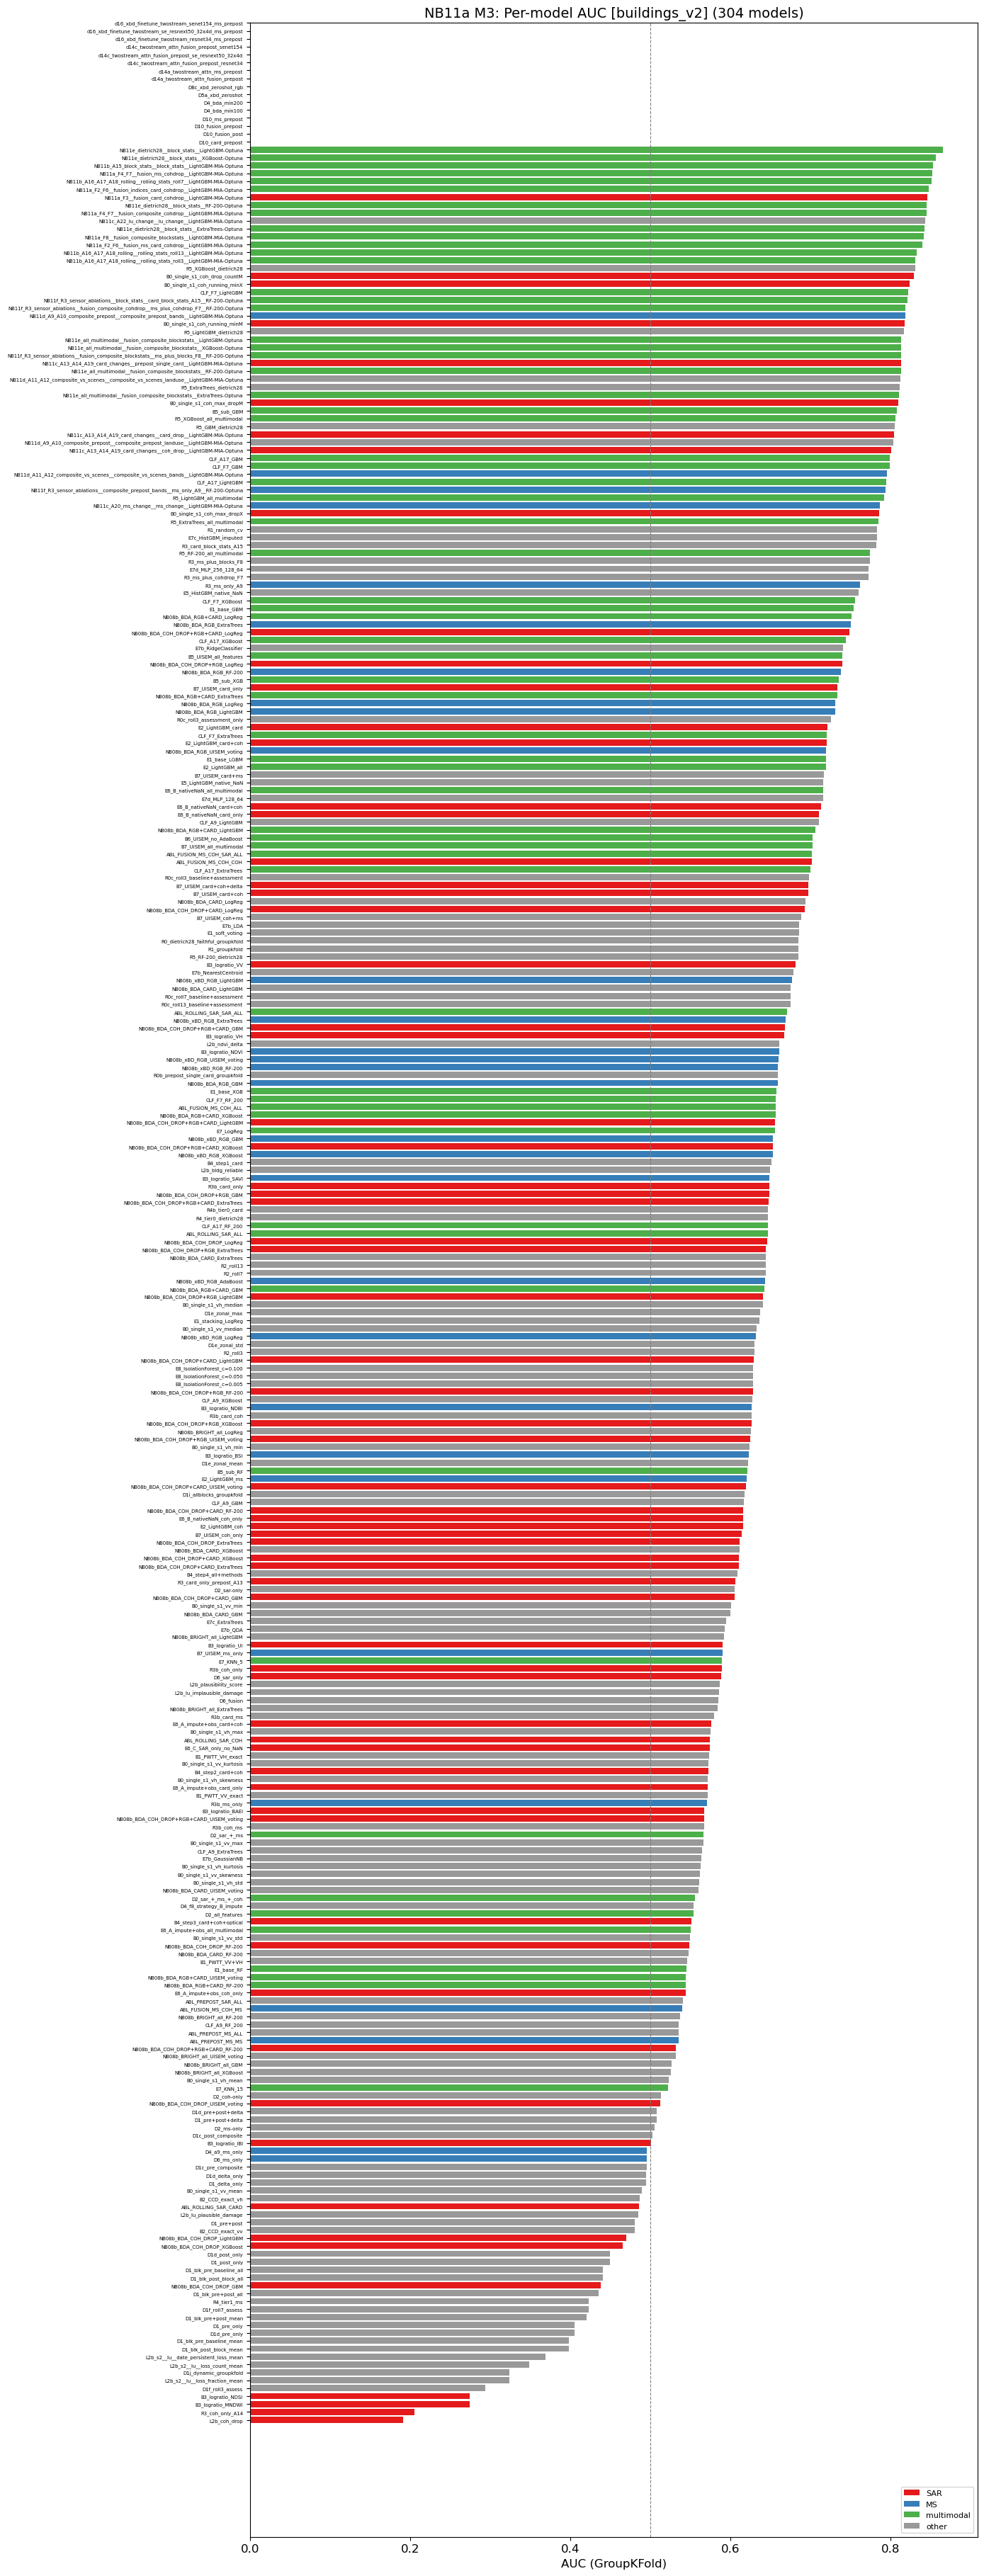

  Plot: cell_m3/M3_per_model_auc_buildings_v2_20260703_084947.png

  --- points_v3plus ---
  [points_v3plus] 219 models: 4 leaky, 5 degenerate
  Saved: cell_m3/M3_per_model_sanity_points_v3plus_20260703_084954.csv (32.0 KB)

  [points_v3plus] modality family breakdown:
    SAR            :  38 models  AUC median=0.514  max=0.588
    MS             :  10 models  AUC median=0.646  max=0.741
    multimodal     :  26 models  AUC median=0.643  max=0.666
    other          : 136 models  AUC median=0.532  max=0.705


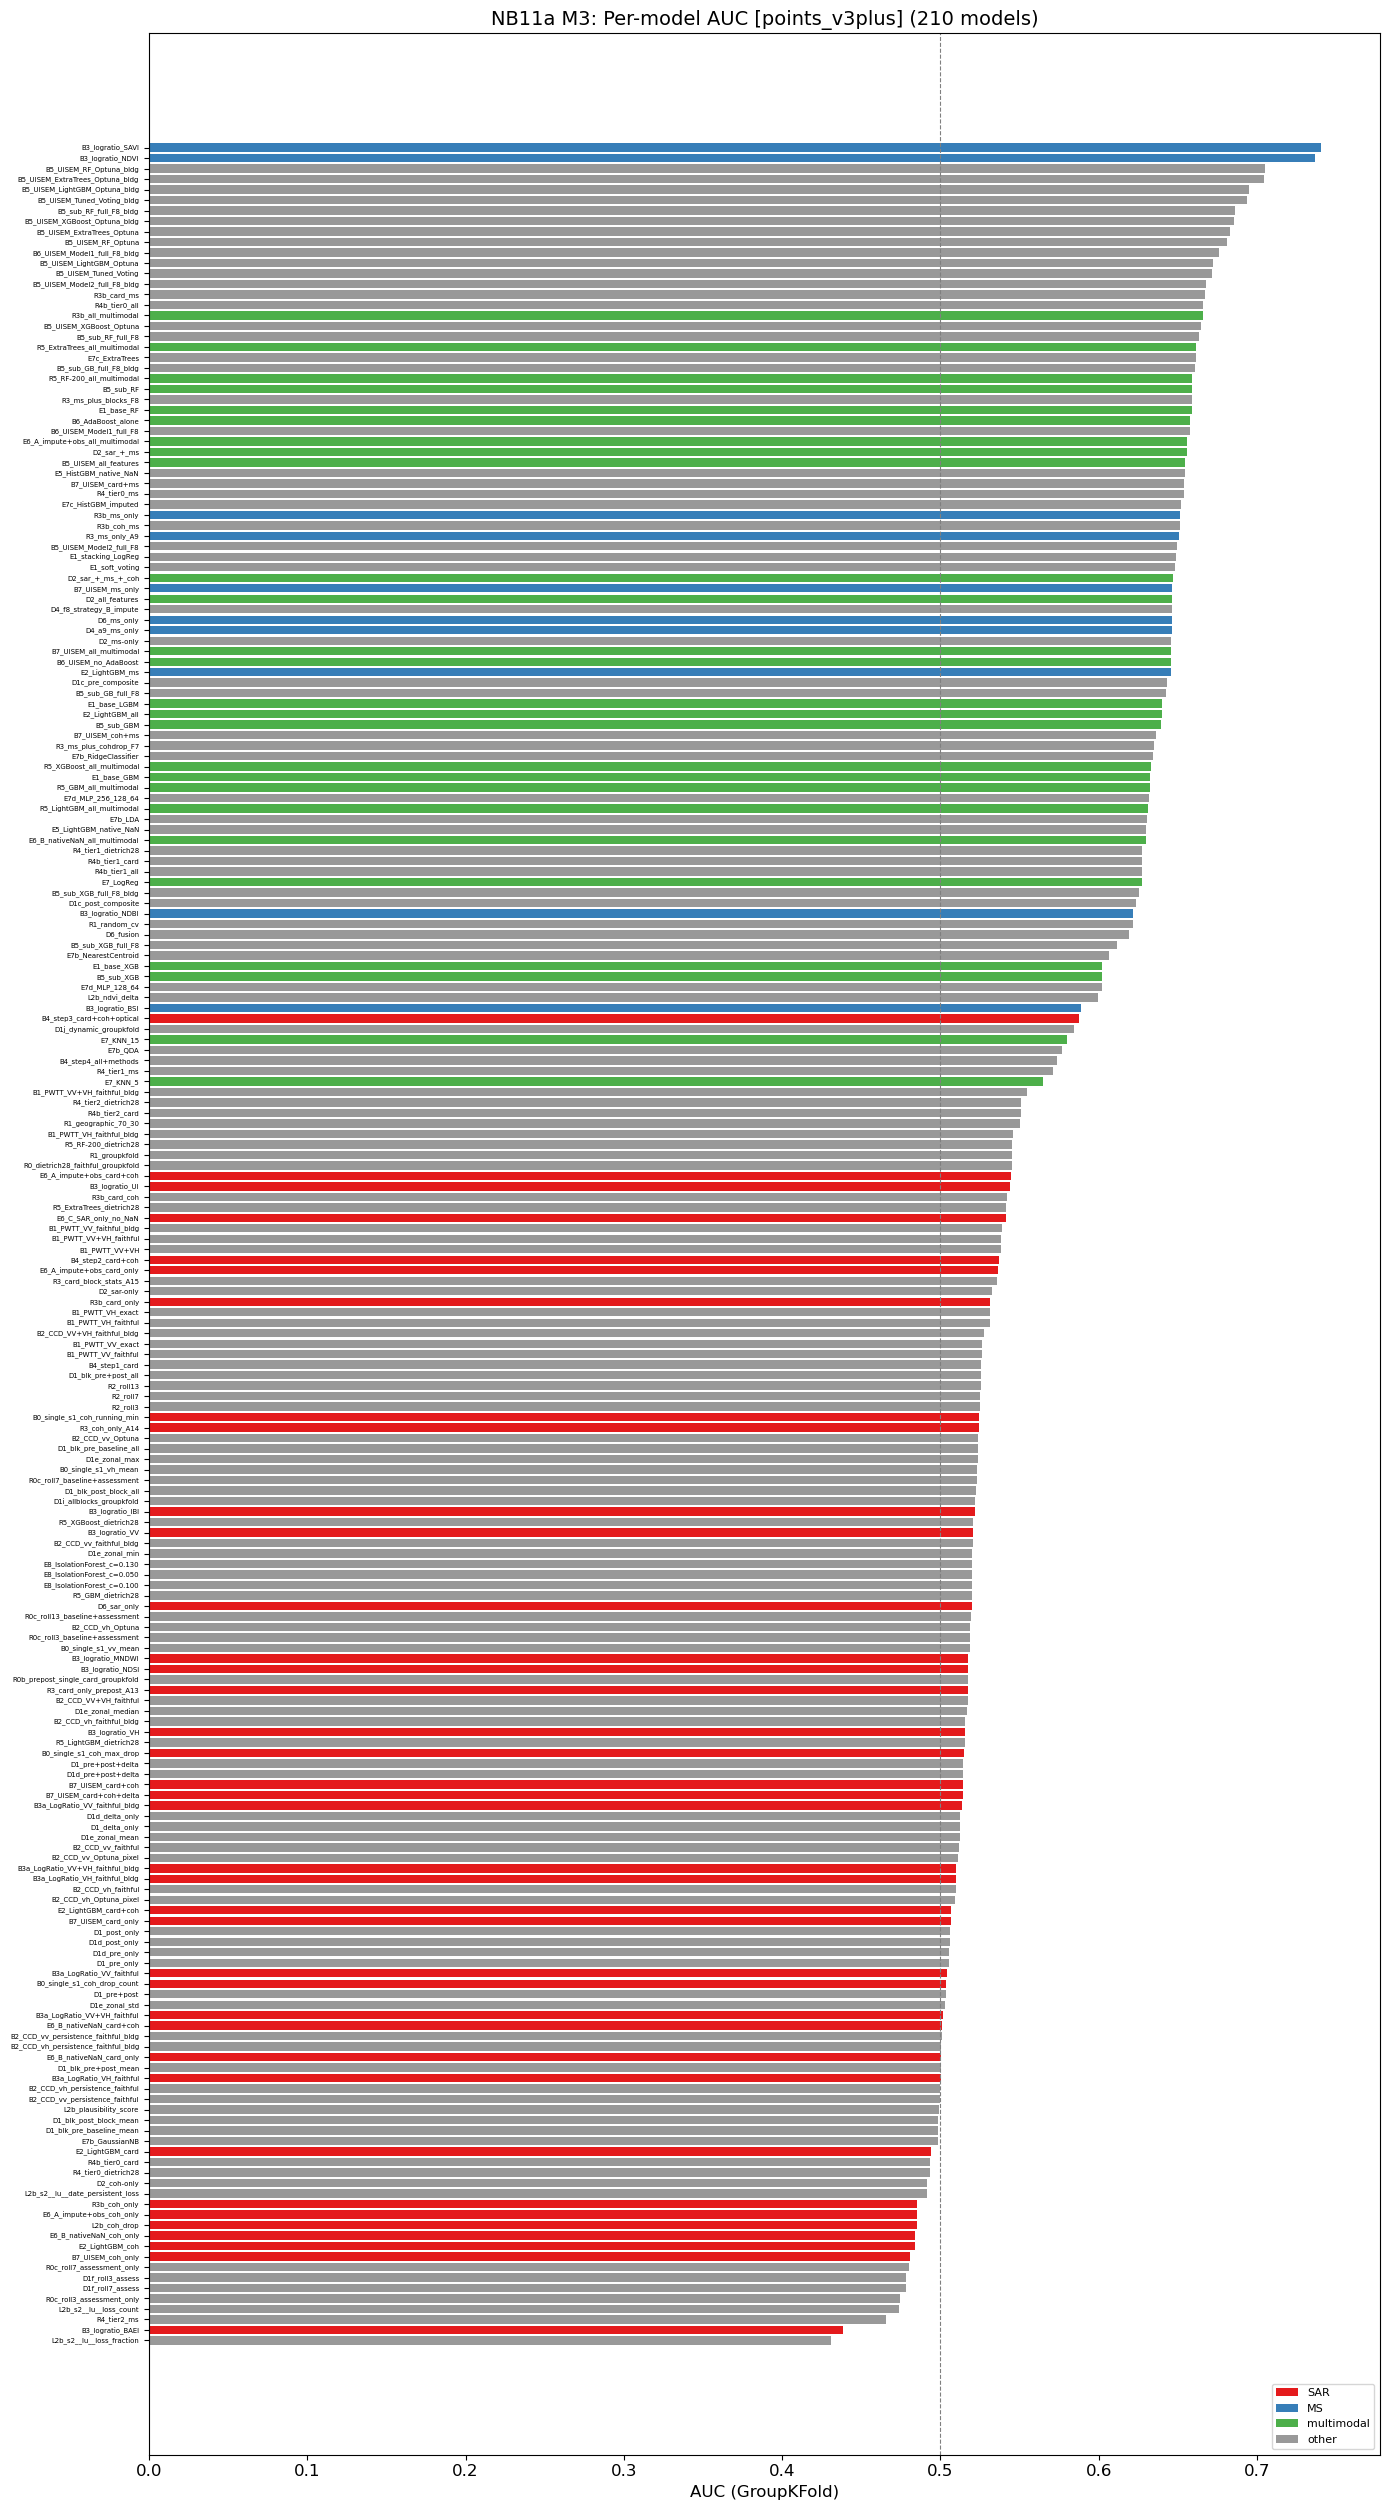

  Plot: cell_m3/M3_per_model_auc_points_v3plus_20260703_084954.png


In [6]:
# @title CELL M3: PER-MODEL SANITY CHECK (PER GROUP + MODALITY)
print("=" * 70)
print("CELL M3: PER-MODEL SANITY CHECK")
print("=" * 70)

model_sanity_all = {}

for grp_name, grp_oof in groups_loaded.items():
    print(f"\n  --- {grp_name} ---")
    ms = build_model_sanity(grp_oof, grp_name, LEAKAGE_VARIANT_MARKERS)
    ms['modality'] = ms.apply(lambda r: classify_modality(r['model_id'], r['variant_id']), axis=1)
    ms['modality_family'] = ms['modality'].apply(modality_family)
    model_sanity_all[grp_name] = ms
    save_result(ms, f'M3_per_model_sanity_{grp_name}', 'cell_m3')

    headline = ms[(~ms['is_leaky']) & (~ms['is_degenerate'])].copy()

    # modality family breakdown
    print(f"\n  [{grp_name}] modality family breakdown:")
    for fam in ['SAR', 'MS', 'multimodal', 'other']:
        sub = headline[headline['modality_family'] == fam]
        if len(sub) > 0:
            print(f"    {fam:15s}: {len(sub):3d} models  "
                  f"AUC median={sub['auc'].median():.3f}  max={sub['auc'].max():.3f}")

    # AUC bar chart colored by modality family
    if len(headline) > 0:
        headline_sorted = headline.sort_values('auc', ascending=True)
        colors = [FAMILY_COLORS.get(f, '#999999') for f in headline_sorted['modality_family']]
        fig, ax = plt.subplots(figsize=(14, max(8, len(headline_sorted) * 0.12)))
        ax.barh(range(len(headline_sorted)), headline_sorted['auc'], color=colors)
        ax.set_yticks(range(len(headline_sorted)))
        ax.set_yticklabels(headline_sorted['model_id'], fontsize=5)
        ax.set_xlabel('AUC (GroupKFold)')
        ax.set_title(f'NB11a M3: Per-model AUC [{grp_name}] ({len(headline_sorted)} models)')
        ax.axvline(0.5, color='grey', ls='--', lw=0.8)
        from matplotlib.patches import Patch
        handles = [Patch(facecolor=FAMILY_COLORS[f], label=f) for f in ['SAR', 'MS', 'multimodal', 'other']]
        ax.legend(handles=handles, loc='lower right', fontsize=8)
        plt.tight_layout()
        save_fig(fig, f'M3_per_model_auc_{grp_name}', 'cell_m3')


# CELL M4: PIVOT TO WIDE (BUILDING × MODEL)
Three wide matrices:
- `pred_wide[building_id, city, y_true] → {model_id: y_pred}` — binary 0/1 predictions
- `proba_wide[...]`  → `y_proba` scalar probabilities
- `cm_wide[...]` → `cm_class` (TP/FN/FP/TN string)

Headline models only (exclude leaky + degenerate).

In [7]:
# @title CELL M4: PIVOT TO (SAMPLE x MODEL) WIDE (PER GROUP)
print("=" * 70)
print("CELL M4: PIVOT TO WIDE")
print("=" * 70)

pivots = {}

for grp_name, grp_oof in groups_loaded.items():
    print(f"\n  --- {grp_name} ---")
    ms = model_sanity_all[grp_name]
    headline = ms[(~ms['is_leaky']) & (~ms['is_degenerate'])]['model_id'].tolist()
    grp_headline = grp_oof[grp_oof['model_id'].isin(headline)].copy()
    model_cols = sorted(grp_headline['model_id'].unique())

    pred_wide  = pivot_oof(grp_headline, 'y_pred')
    proba_wide = pivot_oof(grp_headline, 'y_proba')

    # add y_true column (majority)
    yt_map = grp_headline.groupby(SAMPLE_ID_COL)['y_true'].first()
    pred_wide['y_true']  = pred_wide.index.map(yt_map)
    proba_wide['y_true'] = proba_wide.index.map(yt_map)

    pivots[grp_name] = {
        'pred_wide': pred_wide,
        'proba_wide': proba_wide,
        'model_cols': model_cols,
        'headline_oof': grp_headline,
    }
    print(f"    pred_wide:  {pred_wide.shape}")
    print(f"    proba_wide: {proba_wide.shape}")
    print(f"    model_cols: {len(model_cols)}")


CELL M4: PIVOT TO WIDE

  --- buildings_v2 ---
    pred_wide:  (756443, 305)
    proba_wide: (756443, 305)
    model_cols: 304

  --- points_v3plus ---
    pred_wide:  (104130, 211)
    proba_wide: (104130, 211)
    model_cols: 210


# CELL M5: PAIRWISE COHEN's κ + SPEARMAN ρ
Cohen's κ on `y_pred` (discrete agreement, chance-corrected). Spearman ρ on `y_proba` (continuous rank agreement).

High κ + high ρ → models agree both on binary decisions and on score ordering. High ρ + low κ → models rank-order similarly but draw the threshold differently.

In [8]:
# @title CELL M5: PAIRWISE COHEN's kappa (y_pred) + SPEARMAN rho (y_proba) + MODALITY
from sklearn.metrics import cohen_kappa_score
from scipy.stats import spearmanr

print("=" * 70)
print("CELL M5: PAIRWISE AGREEMENT")
print("=" * 70)

def summarize_pairwise(mat, name):
    vals = mat.values[np.triu_indices_from(mat.values, k=1)]
    vals = vals[~np.isnan(vals.astype(float))]
    if len(vals) == 0:
        print(f"  {name}: no valid pairs")
        return
    print(f"  {name}:")
    print(f"    pairs:      {len(vals)}")
    print(f"    mean:       {vals.mean():.3f}")
    print(f"    median:     {np.median(vals):.3f}")
    print(f"    min / max:  {vals.min():.3f} / {vals.max():.3f}")
    print(f"    P25 / P75:  {np.percentile(vals, 25):.3f} / {np.percentile(vals, 75):.3f}")

for grp_name, pv in pivots.items():
    print(f"\n  --- {grp_name} ---")
    pred_wide = pv['pred_wide']
    proba_wide = pv['proba_wide']
    model_cols = pv['model_cols']
    ms = model_sanity_all[grp_name]
    mod_lookup = dict(zip(ms['model_id'], ms['modality_family']))

    kappa_mat = pd.DataFrame(index=model_cols, columns=model_cols, dtype=float)
    spearman_mat = pd.DataFrame(index=model_cols, columns=model_cols, dtype=float)

    kappa_by_pair_type = {}

    for i, m1 in enumerate(model_cols):
        for j, m2 in enumerate(model_cols):
            if j < i:
                continue
            if i == j:
                kappa_mat.loc[m1, m2] = 1.0
                spearman_mat.loc[m1, m2] = 1.0
                continue
            # kappa on y_pred
            both = pred_wide[[m1, m2]].dropna()
            if len(both) >= 20 and both[m1].nunique() > 1 and both[m2].nunique() > 1:
                k = cohen_kappa_score(both[m1].astype(int), both[m2].astype(int))
            else:
                k = np.nan
            kappa_mat.loc[m1, m2] = k
            kappa_mat.loc[m2, m1] = k

            # track by modality pair type
            f1 = mod_lookup.get(m1, 'other')
            f2 = mod_lookup.get(m2, 'other')
            pt = f"{min(f1,f2)}-{max(f1,f2)}"
            if not np.isnan(k):
                kappa_by_pair_type.setdefault(pt, []).append(k)

            # spearman on y_proba
            both_p = proba_wide[[m1, m2]].dropna()
            if len(both_p) >= 20:
                try:
                    rho, _ = spearmanr(both_p[m1], both_p[m2])
                except Exception:
                    rho = np.nan
            else:
                rho = np.nan
            spearman_mat.loc[m1, m2] = rho
            spearman_mat.loc[m2, m1] = rho

    summarize_pairwise(kappa_mat, f"Cohen's kappa (y_pred) [{grp_name}]")
    summarize_pairwise(spearman_mat, f"Spearman rho (y_proba) [{grp_name}]")

    # modality pair type summary
    print(f"\n  [{grp_name}] kappa by modality pair type:")
    pair_summary_rows = []
    for pt in sorted(kappa_by_pair_type.keys()):
        vals = np.array(kappa_by_pair_type[pt])
        print(f"    {pt:30s}: n={len(vals):4d}  mean={vals.mean():.3f}  median={np.median(vals):.3f}")
        pair_summary_rows.append({
            'pair_type': pt, 'n_pairs': len(vals),
            'kappa_mean': round(vals.mean(), 4), 'kappa_median': round(np.median(vals), 4),
        })
    save_result(pd.DataFrame(pair_summary_rows),
                f'M5_kappa_by_modality_pair_{grp_name}', 'cell_m5')

    save_result(kappa_mat.reset_index().rename(columns={'index': 'model_id'}),
                f'M5_pairwise_kappa_{grp_name}', 'cell_m5')
    save_result(spearman_mat.reset_index().rename(columns={'index': 'model_id'}),
                f'M5_pairwise_spearman_{grp_name}', 'cell_m5')

    pv['kappa_mat'] = kappa_mat
    pv['spearman_mat'] = spearman_mat


CELL M5: PAIRWISE AGREEMENT

  --- buildings_v2 ---
  Cohen's kappa (y_pred) [buildings_v2]:
    pairs:      36271
    mean:       0.088
    median:     0.002
    min / max:  -0.986 / 1.000
    P25 / P75:  -0.000 / 0.104
  Spearman rho (y_proba) [buildings_v2]:
    pairs:      37123
    mean:       0.184
    median:     0.167
    min / max:  -1.000 / 1.000
    P25 / P75:  -0.031 / 0.423

  [buildings_v2] kappa by modality pair type:
    MS-MS                         : n= 259  mean=0.148  median=0.008
    MS-SAR                        : n=1518  mean=0.048  median=0.000
    MS-multimodal                 : n=1404  mean=0.126  median=0.005
    MS-other                      : n=2566  mean=0.088  median=0.002
    SAR-SAR                       : n=2332  mean=0.048  median=0.001
    SAR-multimodal                : n=4355  mean=0.071  median=0.003
    SAR-other                     : n=7788  mean=0.043  median=0.001
    multimodal-multimodal         : n=1976  mean=0.189  median=0.014
    multimo

# CELL M6: JACCARD on FP / FN SETS
For each pair of models, what fraction of FP (or FN) buildings do they share?

High FP Jaccard → models hallucinate damage on the same buildings (shared bias source).
High FN Jaccard → models miss damage on the same buildings (signal-limited buildings).
Low Jaccard → model errors are independent → ensembling helps.

In [9]:
# @title CELL M6: JACCARD on FP / FN SETS (PER GROUP)
print("=" * 70)
print("CELL M6: JACCARD FP/FN SETS")
print("=" * 70)

for grp_name, pv in pivots.items():
    print(f"\n  --- {grp_name} ---")
    pred_wide = pv['pred_wide']
    model_cols = pv['model_cols']
    yt = pred_wide['y_true']

    fp_sets = {}
    fn_sets = {}
    for m in model_cols:
        yp = pred_wide[m].dropna().astype(int)
        yt_m = yt.loc[yp.index]
        fp_sets[m] = set(yp.index[(yp == 1) & (yt_m == 0)])
        fn_sets[m] = set(yp.index[(yp == 0) & (yt_m == 1)])

    def jaccard(s1, s2):
        if len(s1) == 0 and len(s2) == 0:
            return 1.0
        union = len(s1 | s2)
        return len(s1 & s2) / union if union > 0 else 0.0

    fp_jac = pd.DataFrame(index=model_cols, columns=model_cols, dtype=float)
    fn_jac = pd.DataFrame(index=model_cols, columns=model_cols, dtype=float)
    for i, m1 in enumerate(model_cols):
        for j, m2 in enumerate(model_cols):
            if j < i:
                continue
            fp_jac.loc[m1, m2] = fp_jac.loc[m2, m1] = jaccard(fp_sets[m1], fp_sets[m2])
            fn_jac.loc[m1, m2] = fn_jac.loc[m2, m1] = jaccard(fn_sets[m1], fn_sets[m2])

    # summary
    for name, mat in [('FP Jaccard', fp_jac), ('FN Jaccard', fn_jac)]:
        vals = mat.values[np.triu_indices_from(mat.values, k=1)]
        vals = vals[~np.isnan(vals.astype(float))]
        if len(vals) > 0:
            print(f"  {name} [{grp_name}]: mean={vals.mean():.3f} median={np.median(vals):.3f}")

    save_result(fp_jac.reset_index().rename(columns={'index': 'model_id'}),
                f'M6_fp_jaccard_{grp_name}', 'cell_m6')
    save_result(fn_jac.reset_index().rename(columns={'index': 'model_id'}),
                f'M6_fn_jaccard_{grp_name}', 'cell_m6')


CELL M6: JACCARD FP/FN SETS

  --- buildings_v2 ---
  FP Jaccard [buildings_v2]: mean=0.080 median=0.001
  FN Jaccard [buildings_v2]: mean=0.321 median=0.227
  Saved: cell_m6/M6_fp_jaccard_buildings_v2_20260703_140113.csv (1379.3 KB)
  Saved: cell_m6/M6_fn_jaccard_buildings_v2_20260703_140113.csv (1485.6 KB)

  --- points_v3plus ---
  FP Jaccard [points_v3plus]: mean=0.040 median=0.003
  FN Jaccard [points_v3plus]: mean=0.456 median=0.458
  Saved: cell_m6/M6_fp_jaccard_points_v3plus_20260703_140202.csv (648.4 KB)
  Saved: cell_m6/M6_fn_jaccard_points_v3plus_20260703_140202.csv (699.8 KB)


# CELL M7: FLEISS' κ — MULTI-RATER RELIABILITY
Single scalar κ over all N_models × N_buildings rated rows. Answers: "across all supervised models, how much above-chance agreement exists?"

Requires `statsmodels`. If not installed, falls back to mean of pairwise Cohen's κ (approximation).

In [10]:
# @title CELL M7: FLEISS' kappa ACROSS ALL MODELS (PER GROUP)
print("=" * 70)
print("CELL M7: FLEISS' kappa")
print("=" * 70)

def fleiss_kappa(table):
    """Compute Fleiss' kappa for a (n_subjects x n_categories) count matrix."""
    n_sub, n_cat = table.shape
    n_rat = table.sum(axis=1)
    if (n_rat == 0).any():
        table = table[n_rat > 0]
        n_rat = table.sum(axis=1)
        n_sub = len(table)
    N = n_rat.iloc[0]  # assume constant raters
    p_j = table.sum(axis=0) / (n_sub * N)
    P_i = (table ** 2).sum(axis=1)
    P_i = (P_i - N) / (N * (N - 1))
    P_bar = P_i.mean()
    P_e = (p_j ** 2).sum()
    if P_e >= 1.0:
        return 0.0
    return (P_bar - P_e) / (1 - P_e)

for grp_name, pv in pivots.items():
    print(f"\n  --- {grp_name} ---")
    pred_wide = pv['pred_wide']
    model_cols = pv['model_cols']

    # build count table: per sample, count of (0-votes, 1-votes)
    votes = pred_wide[model_cols].copy()
    n_raters = votes.notna().sum(axis=1)
    votes = votes[n_raters >= 3]  # need at least 3 raters
    count_1 = votes.sum(axis=1)
    count_0 = votes.notna().sum(axis=1) - count_1
    table = pd.DataFrame({'cat_0': count_0, 'cat_1': count_1})

    if len(table) > 0:
        fk = fleiss_kappa(table)
        print(f"  Fleiss' kappa [{grp_name}]: {fk:.4f}  (n_samples={len(table):,}, n_models={len(model_cols)})")
        save_result({'fleiss_kappa': fk, 'n_samples': len(table), 'n_models': len(model_cols)},
                    f'M7_fleiss_kappa_{grp_name}', 'cell_m7', fmt='json')
    else:
        print(f"  [{grp_name}] no samples with >= 3 raters")


CELL M7: FLEISS' kappa

  --- buildings_v2 ---
  Fleiss' kappa [buildings_v2]: 0.2045  (n_samples=756,443, n_models=304)
  Saved: cell_m7/M7_fleiss_kappa_buildings_v2_20260703_140214.json (0.1 KB)

  --- points_v3plus ---
  Fleiss' kappa [points_v3plus]: 0.0000  (n_samples=104,130, n_models=210)
  Saved: cell_m7/M7_fleiss_kappa_points_v3plus_20260703_140215.json (0.1 KB)


# CELL M8: HARD-FOR-ALL BUILDINGS
Buildings that (almost) every model misclassifies. These are either signal-limited (physically unpredictable from the data, e.g. small buildings, heavy cloud, no SAR coverage) or UNOSAT label errors (Aimaiti 2022 framing).

Joins with `df_bldg` metadata (area_m2, city, tier) to surface stratification leads for NB11b.

In [11]:
# @title CELL M8: HARD-FOR-ALL SAMPLES (PER GROUP + MODALITY)
print("=" * 70)
print(f"CELL M8: HARD-FOR-ALL  (threshold={HARD_FOR_ALL_THRESHOLD})")
print("=" * 70)

for grp_name, pv in pivots.items():
    print(f"\n  --- {grp_name} ---")
    headline_oof = pv['headline_oof']
    model_cols = pv['model_cols']
    ms = model_sanity_all[grp_name]

    headline_mids = set(model_cols)

    per_bldg = headline_oof.groupby([SAMPLE_ID_COL, 'city', 'y_true']).agg(
        n_models=('cm_class', 'count'),
        n_errors=('cm_class', lambda s: s.isin(['FP', 'FN']).sum()),
    ).reset_index()
    per_bldg['error_rate'] = per_bldg['n_errors'] / per_bldg['n_models'].replace(0, np.nan)

    min_raters = max(3, int(0.1 * len(headline_mids)))
    per_bldg_qual = per_bldg[per_bldg['n_models'] >= min_raters].copy()
    print(f"  Samples with >= {min_raters} model votes: {len(per_bldg_qual):,}")

    hard = per_bldg_qual['error_rate'] >= HARD_FOR_ALL_THRESHOLD
    per_bldg_qual['category'] = 'easy_correct'
    per_bldg_qual.loc[hard & (per_bldg_qual['y_true'] == 1), 'category'] = 'hard_missed'
    per_bldg_qual.loc[hard & (per_bldg_qual['y_true'] == 0), 'category'] = 'hard_phantom'

    cat_counts = per_bldg_qual['category'].value_counts()
    print(f"\n  Categories:")
    for c in ['easy_correct', 'hard_missed', 'hard_phantom']:
        n = int(cat_counts.get(c, 0))
        pct = 100 * n / len(per_bldg_qual) if len(per_bldg_qual) else 0
        print(f"    {c:15s}: {n:7d}  ({pct:5.2f}%)")

    save_result(per_bldg_qual, f'M8_per_sample_error_rate_{grp_name}', 'cell_m8')

    # which modality families miss the hard_missed samples?
    hard_missed_ids = set(per_bldg_qual[per_bldg_qual['category'] == 'hard_missed'][SAMPLE_ID_COL])
    if len(hard_missed_ids) > 0:
        print(f"\n  Hard-missed samples ({len(hard_missed_ids)}) - error rate by modality family:")
        for fam in ['SAR', 'MS', 'multimodal', 'other']:
            fam_mids = ms[(ms['modality_family'] == fam) & (~ms['is_leaky']) & (~ms['is_degenerate'])]['model_id']
            fam_oof = headline_oof[headline_oof['model_id'].isin(fam_mids)]
            fam_hard = fam_oof[fam_oof[SAMPLE_ID_COL].isin(hard_missed_ids)]
            if len(fam_hard) > 0:
                fam_err = fam_hard['cm_class'].isin(['FP', 'FN']).mean()
                print(f"    {fam:15s}: error_rate={fam_err:.3f}  ({len(fam_mids)} models)")


CELL M8: HARD-FOR-ALL  (threshold=0.9)

  --- buildings_v2 ---
  Samples with >= 30 model votes: 598,595

  Categories:
    easy_correct   :  598525  (99.99%)
    hard_missed    :      70  ( 0.01%)
    hard_phantom   :       0  ( 0.00%)
  Saved: cell_m8/M8_per_sample_error_rate_buildings_v2_20260703_140724.csv (37392.1 KB)

  Hard-missed samples (70) - error rate by modality family:
    SAR            : error_rate=0.886  (69 models)
    MS             : error_rate=0.986  (30 models)
    multimodal     : error_rate=0.997  (64 models)
    other          : error_rate=0.901  (141 models)

  --- points_v3plus ---
  Samples with >= 21 model votes: 100,800

  Categories:
    easy_correct   :   99081  (98.29%)
    hard_missed    :    1679  ( 1.67%)
    hard_phantom   :      40  ( 0.04%)
  Saved: cell_m8/M8_per_sample_error_rate_points_v3plus_20260703_141301.csv (6962.5 KB)

  Hard-missed samples (1679) - error rate by modality family:
    SAR            : error_rate=0.802  (38 models)
    MS  

# CELL M9: LEAKAGE DELTA QUANTIFICATION
Compares leaky variants (`random_cv`, `geographic_70_30`, `leakage_demo_*`) against their matched clean (`groupkfold`) counterparts. The AUC gap is the headline finding of the thesis — it quantifies how much of Dietrich's AUC=0.813 reflects **geographic memorization** rather than damage signal.

In [12]:
# @title CELL M9: LEAKAGE DELTA QUANTIFICATION (PER GROUP)
print("=" * 70)
print("CELL M9: LEAKAGE DELTA")
print("=" * 70)

for grp_name in groups_loaded:
    print(f"\n  --- {grp_name} ---")
    ms = model_sanity_all[grp_name]
    leaky = ms[ms['is_leaky']].copy()
    clean = ms[(~ms['is_leaky']) & (~ms['is_degenerate'])].copy()

    if len(leaky) == 0:
        print(f"  [{grp_name}] no leaky models found")
        continue

    # compute delta
    delta_rows = []
    for _, lrow in leaky.iterrows():
        # find matching clean model (same base name without leakage suffix)
        lid = lrow['model_id']
        base = lid.split('_leakage')[0].split('_random')[0].split('_geographic')[0]
        matches = clean[clean['model_id'].str.startswith(base)]
        if len(matches) > 0:
            best_clean = matches.sort_values('auc', ascending=False).iloc[0]
            delta_rows.append({
                'leaky_model': lid,
                'clean_model': best_clean['model_id'],
                'auc_leaky': lrow['auc'],
                'auc_clean': best_clean['auc'],
                'delta_auc': lrow['auc'] - best_clean['auc'],
                'group': grp_name,
            })

    if delta_rows:
        delta_df = pd.DataFrame(delta_rows)
        print(f"  Mean leakage delta AUC: {delta_df['delta_auc'].mean():.4f}")
        save_result(delta_df, f'M9_leakage_delta_{grp_name}', 'cell_m9')
    else:
        print(f"  [{grp_name}] no matching clean/leaky pairs found")


CELL M9: LEAKAGE DELTA

  --- buildings_v2 ---
  Mean leakage delta AUC: 0.0580
  Saved: cell_m9/M9_leakage_delta_buildings_v2_20260703_141324.csv (0.3 KB)

  --- points_v3plus ---
  Mean leakage delta AUC: 0.0638
  Saved: cell_m9/M9_leakage_delta_points_v3plus_20260703_141324.csv (0.3 KB)


# CELL M10: SUMMARY + NB11b POINTERS
Printout of headline findings + output file list. NB11b (future) will stratify the hard-for-all set by landuse class (from NB09e signals), coherence coverage, post-scene availability, and distance to UNOSAT-labeled buildings.

In [13]:
# @title CELL M10: SUMMARY
print("=" * 70)
print("CELL M10: SUMMARY")
print("=" * 70)

for grp_name in groups_loaded:
    print(f"\n  === {grp_name} ===")
    ms = model_sanity_all[grp_name]
    headline = ms[(~ms['is_leaky']) & (~ms['is_degenerate'])]
    print(f"  Models:     {len(headline)} headline ({len(ms)} total)")
    print(f"  Best AUC:   {headline['auc'].max():.3f}  ({headline.loc[headline['auc'].idxmax(), 'model_id']})")
    print(f"  Median AUC: {headline['auc'].median():.3f}")

    # modality family summary
    print(f"\n  Modality family AUC:")
    for fam in ['SAR', 'MS', 'multimodal', 'other']:
        sub = headline[headline['modality_family'] == fam]
        if len(sub) > 0:
            print(f"    {fam:15s}: n={len(sub):3d}  median={sub['auc'].median():.3f}  "
                  f"max={sub['auc'].max():.3f}  best={sub.loc[sub['auc'].idxmax(), 'model_id']}")

    if grp_name in pivots:
        pv = pivots[grp_name]
        if 'kappa_mat' in pv:
            vals = pv['kappa_mat'].values[np.triu_indices_from(pv['kappa_mat'].values, k=1)]
            vals = vals[~np.isnan(vals.astype(float))]
            if len(vals) > 0:
                print(f"\n  Median kappa: {np.median(vals):.3f}")

print(f"\n  Output dir: {OUT_DIR}")
print(f"  All results saved.")


CELL M10: SUMMARY

  === buildings_v2 ===
  Models:     304 headline (342 total)
  Best AUC:   0.865  (NB11e_dietrich28__block_stats__LightGBM-Optuna)
  Median AUC: 0.643

  Modality family AUC:
    SAR            : n= 69  median=0.625  max=0.846  best=NB11a_F3__fusion_card_cohdrop__LightGBM-MIA-Optuna
    MS             : n= 30  median=0.659  max=0.818  best=NB11d_A9_A10_composite_prepost__composite_prepost_bands__LightGBM-MIA-Optuna
    multimodal     : n= 64  median=0.748  max=0.865  best=NB11e_dietrich28__block_stats__LightGBM-Optuna
    other          : n=141  median=0.594  max=0.843  best=NB11c_A22_lu_change__lu_change__LightGBM-MIA-Optuna

  Median kappa: 0.002

  === points_v3plus ===
  Models:     210 headline (219 total)
  Best AUC:   0.741  (B3_logratio_SAVI)
  Median AUC: 0.539

  Modality family AUC:
    SAR            : n= 38  median=0.514  max=0.588  best=B4_step3_card+coh+optical
    MS             : n= 10  median=0.646  max=0.741  best=B3_logratio_SAVI
    multimodal  

# CELL M11: MODALITY x EXTRACTION METHOD COMPARISON
Key finding from NB08c confirmed at scale: SAR signal depends on spatial averaging (V2 zonal stats),
MS signal is pixel-level (V3 point extraction equal or better).

Compares same model_id across V2 (buildings) and V3 (points) groups, broken down by sensor modality.
Publishable result: extraction geometry interacts with sensor type — no single best approach.

CELL M11: MODALITY x EXTRACTION METHOD

  === buildings_v2 ===
            modality  n_models  auc_mean  auc_median  auc_max  auc_min                                                                   best_model
      multimodal_all        55     0.745       0.774    0.865    0.522                               NB11e_dietrich28__block_stats__LightGBM-Optuna
   multimodal_SAR+MS         9     0.666       0.656    0.851    0.544                          NB11a_F4_F7__fusion_ms_cohdrop__LightGBM-MIA-Optuna
        SAR_card+coh         8     0.653       0.636    0.846    0.551                           NB11a_F3__fusion_card_cohdrop__LightGBM-MIA-Optuna
SAR_coh_unsupervised        34     0.628       0.628    0.829    0.191                                                 B0_single_s1_coh_drop_countM
             MS_only        26     0.668       0.660    0.818    0.496 NB11d_A9_A10_composite_prepost__composite_prepost_bands__LightGBM-MIA-Optuna
       SAR_card_only        10     0.681       0.

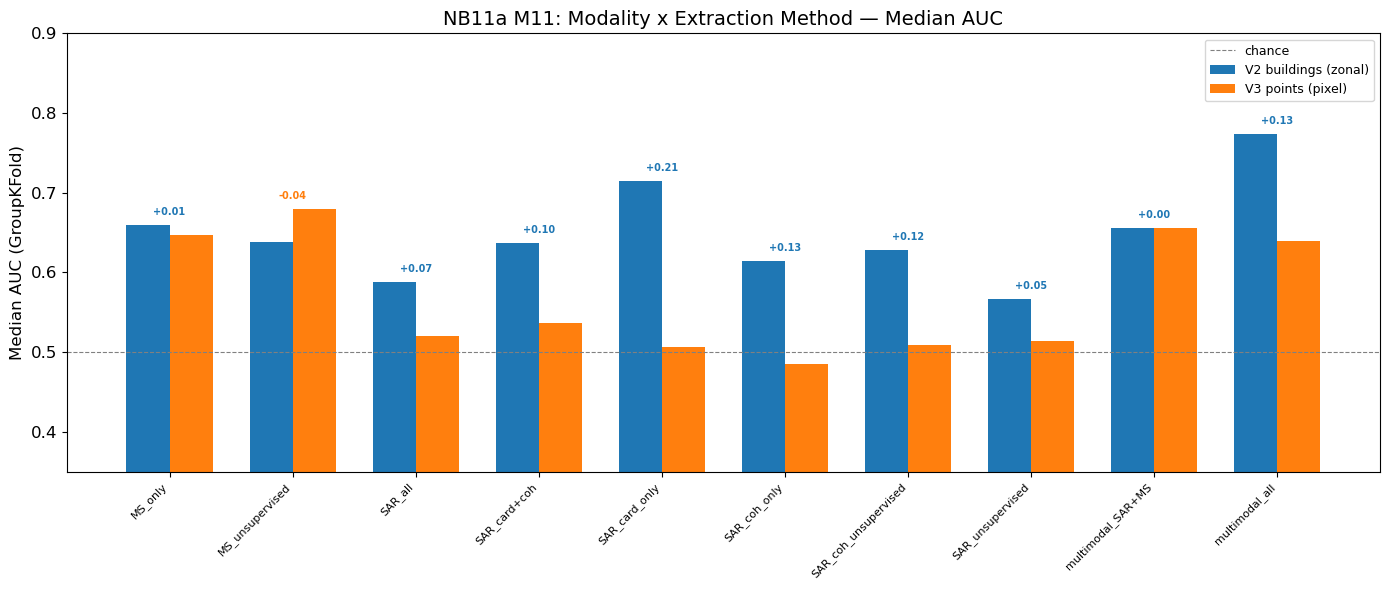

  Plot: cell_m11/M11_modality_v2_vs_v3_chart_20260703_141325.png

  === HEADLINE ===
  SAR models: V2 wins by +0.060 AUC on average (29 models)
  MS models:  V3 wins by +0.048 AUC on average (10 models)
  --> SAR needs spatial averaging (zonal stats over polygon)
  --> MS works at single-pixel level (point extraction sufficient)
  --> Extraction geometry interacts with sensor type


In [14]:
# @title CELL M11: MODALITY x EXTRACTION METHOD COMPARISON
import re

print("=" * 70)
print("CELL M11: MODALITY x EXTRACTION METHOD")
print("=" * 70)

if len(groups_loaded) < 2:
    print("  SKIP: need both buildings_v2 and points_v3plus groups")
else:
    # --- modality classifier ------------------------------------------------
    def classify_modality(model_id, variant_id):
        combined = (str(model_id) + ' ' + str(variant_id)).lower()
        # --- NB11 explicit parquet -> modality lookup (added in v6) --------
        # NB11 model_ids look like 'NB11<a-f>_<tag>__<manifest_key>__<clf>-Optuna'.
        # We check manifest_key tokens FIRST so they take precedence over the
        # token-substring matchers below (which would otherwise miss 'fusion_*').
        _nb11_modality = {
            # SAR-only
            'card_drop':                  'SAR_card_only',
            'prepost_single_card':        'SAR_card_only',
            'coh_drop':                   'SAR_coh_only',
            'rolling_accum_coh':          'SAR_coh_only',
            # SAR + COH fused (no MS)
            'fusion_card_cohdrop':        'SAR_card+coh',
            # multimodal (SAR + MS, +/- COH)
            'fusion_ms_card_cohdrop':     'multimodal_all',
            'fusion_indices_card_cohdrop':'multimodal_all',
            'fusion_ms_cohdrop':          'multimodal_SAR+MS',
            'fusion_composite_cohdrop':   'multimodal_all',
            'fusion_composite_blockstats':'multimodal_all',
            'block_stats':                'multimodal_all',
            'rolling_stats_roll3':        'multimodal_all',
            'rolling_stats_roll7':        'multimodal_all',
            'rolling_stats_roll13':       'multimodal_all',
            # MS-only
            'ms_change':                  'MS_only',
            'composite_prepost_bands':    'MS_only',
            'composite_vs_scenes_bands':  'MS_only',
            # land-use (own family)
            'lu_change':                  'other',
            'composite_prepost_landuse':  'other',
            'composite_vs_scenes_landuse':'other',
        }
        if 'nb11' in combined:
            for _key, _mod in _nb11_modality.items():
                if _key in combined:
                    return _mod
        if any(x in combined for x in ['coh_drop', 'coh_running', 'coh_max_drop']):
            return 'SAR_coh_unsupervised'
        if 'logratio' in combined:
            if any(x in combined for x in ['ndvi', 'savi', 'bsi', 'nbr', 'ndbi']):
                return 'MS_unsupervised'
            return 'SAR_unsupervised'
        if 'card_only' in combined or 'sensor=card' in combined:
            return 'SAR_card_only'
        if 'coh_only' in combined or 'sensor=coh' in combined:
            return 'SAR_coh_only'
        if 'card+coh' in combined or 'sensor=card+coh' in combined:
            return 'SAR_card+coh'
        if 'ms_only' in combined or 'sensor=ms' in combined:
            return 'MS_only'
        if 'nb08b' in combined:
            if 'rgb' in combined and ('card' in combined or 'coh' in combined):
                return 'multimodal_SAR+MS'
            if 'rgb' in combined:
                return 'MS_only'
        if 'all_multimodal' in combined or 'all features' in combined:
            return 'multimodal_all'
        if 'parquet=f7' in combined or 'parquet=a17' in combined:
            return 'multimodal_all'
        if 'sar_only' in combined:
            return 'SAR_all'
        if 'sar + ms + coh' in combined:
            return 'multimodal_all'
        if 'sar + ms' in combined:
            return 'multimodal_SAR+MS'
        return 'other'

    # --- build per-group sanity with modality tags ---
    tagged = {}
    for grp_name in groups_loaded:
        ms = model_sanity_all[grp_name].copy()
        ms = ms[(~ms['is_leaky']) & (~ms['is_degenerate'])].copy()
        ms['modality'] = ms.apply(lambda r: classify_modality(r['model_id'], r['variant_id']), axis=1)
        tagged[grp_name] = ms

    # --- per-group modality summary ---
    for grp_name, ms in tagged.items():
        print(f"\n  === {grp_name} ===")
        summary_rows = []
        for mod, g in ms.groupby('modality'):
            aucs = g['auc'].values
            summary_rows.append({
                'modality': mod, 'n_models': len(g),
                'auc_mean': round(aucs.mean(), 3),
                'auc_median': round(np.median(aucs), 3),
                'auc_max': round(aucs.max(), 3),
                'auc_min': round(aucs.min(), 3),
                'best_model': g.loc[g['auc'].idxmax(), 'model_id'],
            })
        sdf = pd.DataFrame(summary_rows).sort_values('auc_max', ascending=False)
        print(sdf.to_string(index=False))
        save_result(sdf, f'M11_modality_summary_{grp_name}', 'cell_m11')

    # --- direct V2 vs V3 comparison for same model_id ---
    v2_ms = tagged[GROUP_A][['model_id', 'auc', 'modality']].copy()
    v3_ms = tagged[GROUP_B][['model_id', 'auc']].copy()
    both = v2_ms.merge(v3_ms, on='model_id', suffixes=('_v2', '_v3'))
    both['delta_v2_minus_v3'] = both['auc_v2'] - both['auc_v3']

    print(f"\n  === DIRECT COMPARISON: same model in V2 vs V3 ({len(both)} models) ===")
    delta_rows = []
    for mod, g in both.groupby('modality'):
        d = g['delta_v2_minus_v3'].values
        best = g.loc[g['delta_v2_minus_v3'].abs().idxmax()]
        delta_rows.append({
            'modality': mod, 'n_models': len(g),
            'delta_mean': round(d.mean(), 3),
            'delta_median': round(np.median(d), 3),
            'v2_wins': int((d > 0.01).sum()),
            'v3_wins': int((d < -0.01).sum()),
            'tied': int((abs(d) <= 0.01).sum()),
        })
    ddf = pd.DataFrame(delta_rows).sort_values('delta_mean', ascending=False)
    print(ddf.to_string(index=False))
    save_result(ddf, 'M11_modality_v2_vs_v3_delta', 'cell_m11')
    save_result(both.sort_values('delta_v2_minus_v3', ascending=False),
                'M11_per_model_v2_vs_v3', 'cell_m11')

    # --- bar chart: median AUC per modality, V2 vs V3 side by side ---
    import matplotlib.pyplot as plt

    modalities_common = sorted(set(v2_ms['modality']) & set(tagged[GROUP_B]['modality']))
    modalities_common = [m for m in modalities_common if m != 'other']

    if modalities_common:
        v2_medians = [tagged[GROUP_A][tagged[GROUP_A]['modality'] == m]['auc'].median() for m in modalities_common]
        v3_medians = [tagged[GROUP_B][tagged[GROUP_B]['modality'] == m]['auc'].median() for m in modalities_common]

        x = np.arange(len(modalities_common))
        w = 0.35
        fig, ax = plt.subplots(figsize=(14, 6))
        bars_v2 = ax.bar(x - w/2, v2_medians, w, label='V2 buildings (zonal)', color='#1f77b4')
        bars_v3 = ax.bar(x + w/2, v3_medians, w, label='V3 points (pixel)', color='#ff7f0e')
        ax.set_xticks(x)
        ax.set_xticklabels(modalities_common, rotation=45, ha='right', fontsize=8)
        ax.set_ylabel('Median AUC (GroupKFold)')
        ax.set_title('NB11a M11: Modality x Extraction Method — Median AUC')
        ax.axhline(0.5, color='grey', ls='--', lw=0.8, label='chance')
        ax.legend(fontsize=9)
        ax.set_ylim(0.35, 0.90)

        # annotate delta on each pair
        for i_bar in range(len(modalities_common)):
            delta = v2_medians[i_bar] - v3_medians[i_bar]
            top = max(v2_medians[i_bar], v3_medians[i_bar]) + 0.01
            color = '#1f77b4' if delta > 0 else '#ff7f0e'
            ax.text(x[i_bar], top, f'{delta:+.2f}', ha='center', va='bottom',
                    fontsize=7, fontweight='bold', color=color)

        plt.tight_layout()
        save_fig(fig, 'M11_modality_v2_vs_v3_chart', 'cell_m11')

    # --- headline finding ---
    sar_delta = both[both['modality'].str.startswith('SAR')]['delta_v2_minus_v3']
    ms_delta = both[both['modality'].str.startswith('MS')]['delta_v2_minus_v3']
    print(f"\n  === HEADLINE ===")
    if len(sar_delta) > 0:
        print(f"  SAR models: V2 wins by {sar_delta.mean():+.3f} AUC on average ({len(sar_delta)} models)")
    if len(ms_delta) > 0:
        print(f"  MS models:  V3 wins by {-ms_delta.mean():+.3f} AUC on average ({len(ms_delta)} models)")
    print(f"  --> SAR needs spatial averaging (zonal stats over polygon)")
    print(f"  --> MS works at single-pixel level (point extraction sufficient)")
    print(f"  --> Extraction geometry interacts with sensor type")
